
## Imports 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression, Ridge, Lasso, BayesianRidge
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


## Régression — Prédiction de `Prix_Revente`


### Chargement des données

In [2]:
df_clean = pd.read_csv("../data/df_clean.csv")

### Features / Target

In [3]:
target = "Prix_Revente"
features = [c for c in df_clean.columns if c not in [target, "Rapport_Collecte"]]

X = df_clean[features]
y = df_clean[target]

print("Features:", features)
print("Shape X:", X.shape)

Features: ['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie', 'Source']
Shape X: (4156, 7)


### SPLIT 70 / 15 / 15 

In [4]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, random_state=42
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, random_state=42
)

print("\nSplit:")
print("Train:", X_train.shape)
print("Val  :", X_val.shape)
print("Test :", X_test.shape)


Split:
Train: (2909, 7)
Val  : (623, 7)
Test : (624, 7)


### Scaling

In [5]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)


### Fonction d’évaluation

In [6]:
def eval_reg(name, model, Xtr, ytr, Xte, yte):
    model.fit(Xtr, ytr)
    y_pred = model.predict(Xte)

    mse = mean_squared_error(yte, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(yte, y_pred)
    r2 = r2_score(yte, y_pred)

    print(f"{name:25s} | RMSE={rmse:.4f} | MAE={mae:.4f} | MSE={mse:.4f} | R2={r2:.4f}")

    return {
        "RMSE": rmse,
        "MAE": mae,
        "MSE": mse,
        "R2": r2,
        "y_pred": y_pred
    }

### MODELES COMPLETS

In [7]:
models = {
    "Régression linéaire": LinearRegression(),

    "Régression Ridge": Ridge(alpha=1),

    "Régression Lasso": Lasso(alpha=0.1, max_iter=5000),

    "Régression polynomiale": Pipeline([
        ("poly", PolynomialFeatures(degree=2)),
        ("lr", LinearRegression())
    ]),

    "Bayesian Ridge": BayesianRidge(),

    "DecisionTreeRegressor": DecisionTreeRegressor(random_state=42),

    "RandomForestRegressor": RandomForestRegressor(
        n_estimators=100, random_state=42, n_jobs=-1
    ),

    "GradientBoosting": GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42),

    "KNN": KNeighborsRegressor(n_neighbors=5),

    "SVR (RBF)": SVR(kernel="rbf")
}

### TRAIN + EVALUATION

In [8]:
print("\n=== REGRESSION RESULTS ===")

reg_results = {}

for name, model in models.items():
    reg_results[name] = eval_reg(
        name,
        model,
        X_train_scaled,
        y_train,
        X_test_scaled,
        y_test
    )


=== REGRESSION RESULTS ===
Régression linéaire       | RMSE=1.0538 | MAE=0.6403 | MSE=1.1106 | R2=0.9524
Régression Ridge          | RMSE=1.0543 | MAE=0.6416 | MSE=1.1115 | R2=0.9524
Régression Lasso          | RMSE=1.1117 | MAE=0.7483 | MSE=1.2358 | R2=0.9471
Régression polynomiale    | RMSE=0.8949 | MAE=0.4534 | MSE=0.8008 | R2=0.9657
Bayesian Ridge            | RMSE=1.0540 | MAE=0.6408 | MSE=1.1109 | R2=0.9524
DecisionTreeRegressor     | RMSE=0.9564 | MAE=0.2559 | MSE=0.9148 | R2=0.9608
RandomForestRegressor     | RMSE=0.7934 | MAE=0.2431 | MSE=0.6294 | R2=0.9730
GradientBoosting          | RMSE=0.6759 | MAE=0.2979 | MSE=0.4569 | R2=0.9804
KNN                       | RMSE=0.7878 | MAE=0.3604 | MSE=0.6206 | R2=0.9734
SVR (RBF)                 | RMSE=0.8649 | MAE=0.3417 | MSE=0.7481 | R2=0.9679


### Summary

In [9]:
results_df = pd.DataFrame({
    k: {m: v for m, v in r.items() if m != "y_pred"}
    for k, r in reg_results.items()
}).T.sort_values("R2", ascending=False)

display(results_df)

,RMSE,MAE,MSE,R2
GradientBoosting,0.675909,0.297877,0.456853,0.980426
KNN,0.787808,0.360426,0.620641,0.973408
RandomForestRegressor,0.793363,0.243108,0.629425,0.973032
SVR (RBF),0.864929,0.341746,0.748102,0.967947
Régression polynomiale,0.894900,0.453356,0.800845,0.965688
DecisionTreeRegressor,0.956445,0.255885,0.914787,0.960806
Régression linéaire,1.053844,0.640310,1.110588,0.952416
Bayesian Ridge,1.054015,0.640811,1.110948,0.952401
Régression Ridge,1.054291,0.641598,1.111530,0.952376
Régression Lasso,1.111654,0.748263,1.235775,0.947053


### GridSearch (Tuning)

In [ ]:
from sklearn.model_selection import GridSearchCV

print("\n=== GridSearch - Gradient Boosting Regressor ===")


param_grid_gbr = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_gbr = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid_gbr,
    cv=3,                 
    scoring='r2',
    n_jobs=-1             # utilise tous les cores
)

# entraînement
grid_gbr.fit(X_train_scaled, y_train)

# meilleur modèle
best_gbr = grid_gbr.best_estimator_

print("Best params:", grid_gbr.best_params_)
print("Best CV R2:", grid_gbr.best_score_)

# prédiction
y_pred_gbr_grid = best_gbr.predict(X_test_scaled)

# métriques complètes
mse = mean_squared_error(y_test, y_pred_gbr_grid)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred_gbr_grid)
r2 = r2_score(y_test, y_pred_gbr_grid)

print("\nGradient Boosting (GridSearch)")
print("RMSE:", rmse)
print("MAE :", mae)
print("MSE :", mse)
print("R2  :", r2)

# ajout dans résultats
reg_results['Gradient Boosting (GridSearch)'] = {
    "RMSE": rmse,
    "MAE": mae,
    "MSE": mse,
    "R2": r2,
    "y_pred": y_pred_gbr_grid
}


=== GridSearch - Gradient Boosting Regressor ===


### GRAPHIQUE RÉELS vs PRÉDITS

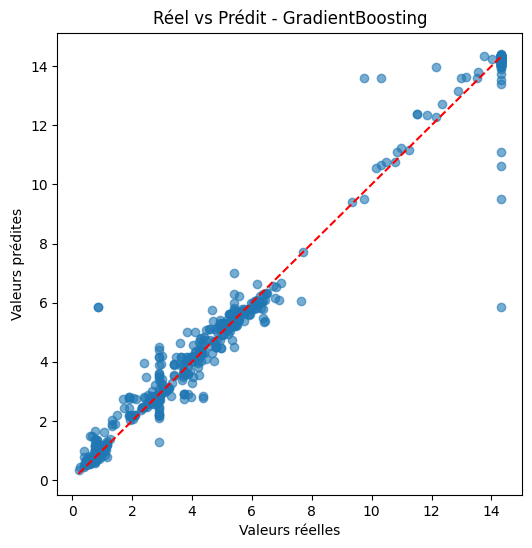

In [ ]:
best_model_name = results_df.index[0]
best_preds = reg_results[best_model_name]["y_pred"]

plt.figure(figsize=(6,6))
plt.scatter(y_test, best_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--')

plt.xlabel("Valeurs réelles")
plt.ylabel("Valeurs prédites")
plt.title(f"Réel vs Prédit - {best_model_name}")
plt.show()